In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

method = 'pearson'  # method correlation

print(f"Using method: {method}")

# Read data
df = pd.read_excel('Glasgow_MRC_joint_norms_inner_join_english_output.xlsx')

# Select familiarity feature columns
features_cols = [col for col in df.columns if col.startswith('fam') or col.startswith('FAM')]
df_features = df[features_cols].apply(pd.to_numeric, errors='coerce')

# Select logprob-based familiarity features
features_logprobs_cols = [col for col in df.columns if col.startswith('logprobs') or col.startswith('FAM')]
df_features_logprobs = df[features_logprobs_cols]
df_features_logprobs.columns = [col.replace('logprobs_', 'fam_') for col in df_features_logprobs.columns]
df_features_logprobs = df_features_logprobs.apply(pd.to_numeric, errors='coerce')

df_features
df_features_logprobs



Using method: pearson


,FAM_Glas,FAM_MRC,fam_v01_short_prompt_gpt4omini,fam_v02_standard_prompt_gpt4omini,fam_v03_return_word_gpt4omini,fam_v04_return_json_gpt4omini,fam_v05_no_quotation_no_colon_gpt4omini,fam_v06_prompt_spanish_gpt4omini,fam_v07_decimals_gpt4omini,fam_v08_rescale_gpt4omini,fam_v09_few_shot_gpt4omini,fam_v02_standard_prompt_llama3.1-8B,fam_v04_return_json_llama3.1-8B
0,3.097,2.84,NaN,4.262189,NaN,NaN,3.977207,3.687781,NaN,44.313512,4.433797,5.494145,NaN
1,4.636,4.26,NaN,5.044958,NaN,NaN,5.437264,5.116437,NaN,55.605513,5.017276,5.501627,NaN
2,4.441,4.13,NaN,4.973627,NaN,NaN,4.560862,4.111735,NaN,46.168952,4.972853,5.627749,NaN
3,2.485,2.08,NaN,4.064941,NaN,NaN,4.214725,3.824043,NaN,39.467808,4.067329,5.471737,NaN
4,6.000,5.63,NaN,6.924140,NaN,NaN,6.562148,6.147990,NaN,60.368811,6.679172,5.755369,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540,2.688,3.88,NaN,5.147941,NaN,NaN,5.851949,4.735907,NaN,57.278510,5.182386,5.728776,NaN
2541,5.192,3.33,NaN,6.679093,NaN,NaN,6.222381,6.437552,NaN,60.499254,6.437808,6.096500,NaN
2542,6.269,5.69,NaN,6.999964,NaN,NaN,6.097540,6.999948,NaN,69.856934,6.999993,5.983157,NaN
2543,5.655,5.65,NaN,6.999953,NaN,NaN,6.999963,6.999290,NaN,68.974940,6.999996,6.180118,NaN


In [46]:
# to configure
#columns = ['FAM_MRC', 'fam_v09_few_shot_gpt4omini']
columns = ['FAM_Glas', 'fam_v02_standard_prompt_gpt4omini']
df_error_analysis = df_features_logprobs.copy()[columns]
df_error_analysis

,FAM_Glas,fam_v02_standard_prompt_gpt4omini
0,3.097,4.262189
1,4.636,5.044958
2,4.441,4.973627
3,2.485,4.064941
4,6.000,6.924140
...,...,...
2540,2.688,5.147941
2541,5.192,6.679093
2542,6.269,6.999964
2543,5.655,6.999953


Mean Absolute Error (MAE): 0.87442967993853
Standard Deviation of Errors: 0.5267031011511049
Mean Signed Error: 0.8592530053029881


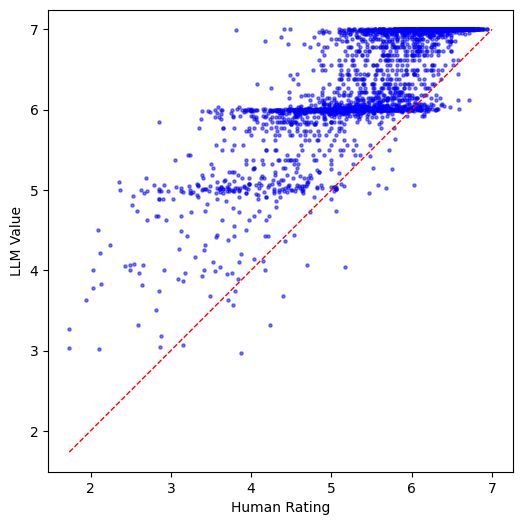

In [47]:
# Compute prediction error (prediction - true value)
df_error_analysis["error"] = (
    df_error_analysis[columns[1]] - df_error_analysis[columns[0]]
)

# Absolute error
df_error_analysis["absolute_error"] = df_error_analysis["error"].abs()

# --- Error metrics ---

# Mean Absolute Error (MAE)
mae = df_error_analysis["absolute_error"].mean()

# Standard deviation of errors
sd_error = df_error_analysis["error"].std()

# Mean signed error (bias: overestimation vs underestimation)
mean_signed_error = df_error_analysis["error"].mean()

print("Mean Absolute Error (MAE):", mae)
print("Standard Deviation of Errors:", sd_error)
print("Mean Signed Error:", mean_signed_error)


min_val = min(df_error_analysis[columns[0]].min(), df_error_analysis[columns[1]].min())
max_val = max(df_error_analysis[columns[0]].max(), df_error_analysis[columns[1]].max())

# Scatter plot: true value vs predicted value
plt.figure(figsize=(6,6))
plt.scatter(
    df_error_analysis[columns[0]],
    df_error_analysis[columns[1]],
    alpha=0.5,
    color='blue',
    s=5
)

# Diagonal line representing perfect prediction (y = x) over full range
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

plt.xlabel("Human Rating")
plt.ylabel("LLM Value")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axis("equal")  # same scale for x and y
plt.savefig(f"{columns[0]}-{columns[1]}_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

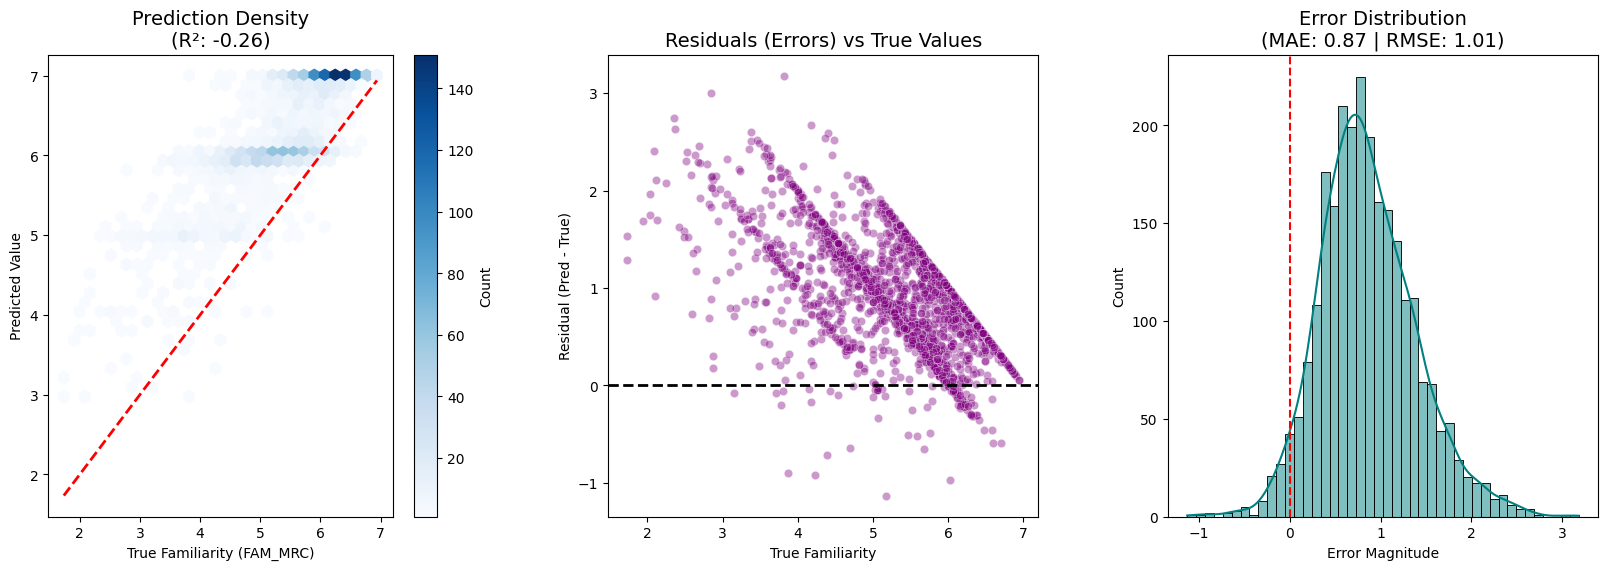

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define variables based on your dataframe
y_true = df_error_analysis[columns[0]]
y_pred = df_error_analysis[columns[1]]
residuals = y_pred - y_true

# 2. Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# 3. Setup Plotting Grid
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.3)

# --- CHART 1: Hexbin Plot (Better Version of your Scatter) ---
# This shows density to solve the overplotting issue in your original image
hb = axes[0].hexbin(y_true, y_pred, gridsize=30, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Count')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_title(f'Prediction Density\n(R²: {r2:.2f})', fontsize=14)
axes[0].set_xlabel('True Familiarity (FAM_MRC)')
axes[0].set_ylabel('Predicted Value')

# --- CHART 2: Residual Plot ---
# Shows if errors are systematic (e.g., if you always fail at low values)
sns.scatterplot(x=y_true, y=residuals, alpha=0.4, ax=axes[1], color='purple')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals (Errors) vs True Values', fontsize=14)
axes[1].set_xlabel('True Familiarity')
axes[1].set_ylabel('Residual (Pred - True)')

# --- CHART 3: Error Distribution ---
# Quantifies the "spread" of your error
sns.histplot(residuals, kde=True, ax=axes[2], color='teal')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title(f'Error Distribution\n(MAE: {mae:.2f} | RMSE: {rmse:.2f})', fontsize=14)
axes[2].set_xlabel('Error Magnitude')

plt.show()

# FT

In [49]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



# Read data
df_ft = pd.read_excel('1_test_random_MRC_Glas.xlsx')

# Select familiarity columns
features_cols = [col for col in df_ft.columns if col.startswith('fam_') or col.startswith('FAM') or col.startswith('logprobs_')]
df_features_ft = df_ft[features_cols].apply(pd.to_numeric, errors='coerce')


df_features_ft





,FAM_Glas,FAM_MRC,logprobs_v02_standard_prompt_gpt4omini,logprobs_v09_few_shot_gpt4omini,fam_ft_v01_glas_gpt4omini,fam_ft_v01_mrc_gpt4omini,fam_ft_v01_glas_mrc_mean_gpt4omini,fam_v02_standard_prompt_llama3.1-8B,logprobs_v02_standard_prompt_llama3.1-8B,fam_ft_v01_glas_mrc_mean_llama3.1-8B
0,5.267,4.42,6.012738,5.999740,4.97,4.21,4.56,6,6.029150,4.85
1,5.794,5.51,6.977020,6.994779,5.62,5.36,5.50,6,6.109886,5.38
2,4.936,5.62,6.075152,6.147822,5.24,5.11,5.12,6,5.885050,5.19
3,4.704,5.34,6.002615,5.998704,4.97,4.90,5.01,6,6.039158,5.19
4,5.063,4.83,5.952907,5.777310,4.62,5.03,5.01,6,5.695173,4.95
...,...,...,...,...,...,...,...,...,...,...
1040,5.593,5.10,6.093186,5.971489,5.62,5.11,5.23,6,5.726709,5.19
1041,5.290,3.88,5.994110,5.996963,5.34,5.03,5.12,6,5.855760,5.19
1042,6.143,5.45,6.880788,6.962672,6.03,5.58,5.73,6,6.161959,5.71
1043,5.824,5.58,6.777291,6.851949,5.91,5.24,5.50,6,5.947594,5.71


In [ ]:
# to configure
#columns = ['FAM_MRC', 'fam_ft_v01_mrc_gpt4omini']
columns = ['FAM_Glas', 'fam_ft_v01_glas_gpt4omini']
df_error_analysis = df_features_ft.copy()[columns]
df_error_analysis

,FAM_MRC,fam_ft_v01_mrc_gpt4omini
0,4.42,4.21
1,5.51,5.36
2,5.62,5.11
3,5.34,4.90
4,4.83,5.03
...,...,...
1040,5.10,5.11
1041,3.88,5.03
1042,5.45,5.58
1043,5.58,5.24


Mean Absolute Error (MAE): 0.2503349282296651
Standard Deviation of Errors: 0.34826118436634856
Mean Signed Error: -0.005301435406698502


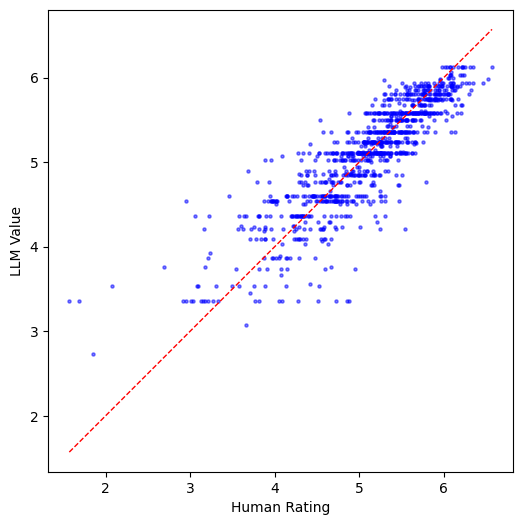

In [51]:
# Compute prediction error (prediction - true value)
df_error_analysis["error"] = (
    df_error_analysis[columns[1]] - df_error_analysis[columns[0]]
)

# Absolute error
df_error_analysis["absolute_error"] = df_error_analysis["error"].abs()

# --- Error metrics ---

# Mean Absolute Error (MAE)
mae = df_error_analysis["absolute_error"].mean()

# Standard deviation of errors
sd_error = df_error_analysis["error"].std()

# Mean signed error (bias: overestimation vs underestimation)
mean_signed_error = df_error_analysis["error"].mean()

print("Mean Absolute Error (MAE):", mae)
print("Standard Deviation of Errors:", sd_error)
print("Mean Signed Error:", mean_signed_error)


min_val = min(df_error_analysis[columns[0]].min(), df_error_analysis[columns[1]].min())
max_val = max(df_error_analysis[columns[0]].max(), df_error_analysis[columns[1]].max())

# Scatter plot: true value vs predicted value
plt.figure(figsize=(6,6))
plt.scatter(
    df_error_analysis[columns[0]],
    df_error_analysis[columns[1]],
    alpha=0.5,
    color='blue',
    s=5
)

# Diagonal line representing perfect prediction (y = x) over full range
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

plt.xlabel("Human Rating")
plt.ylabel("LLM Value")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axis("equal")  # same scale for x and y
plt.savefig(f"{columns[0]}-{columns[1]}_scatter_ft.png", dpi=300, bbox_inches='tight')
plt.show()

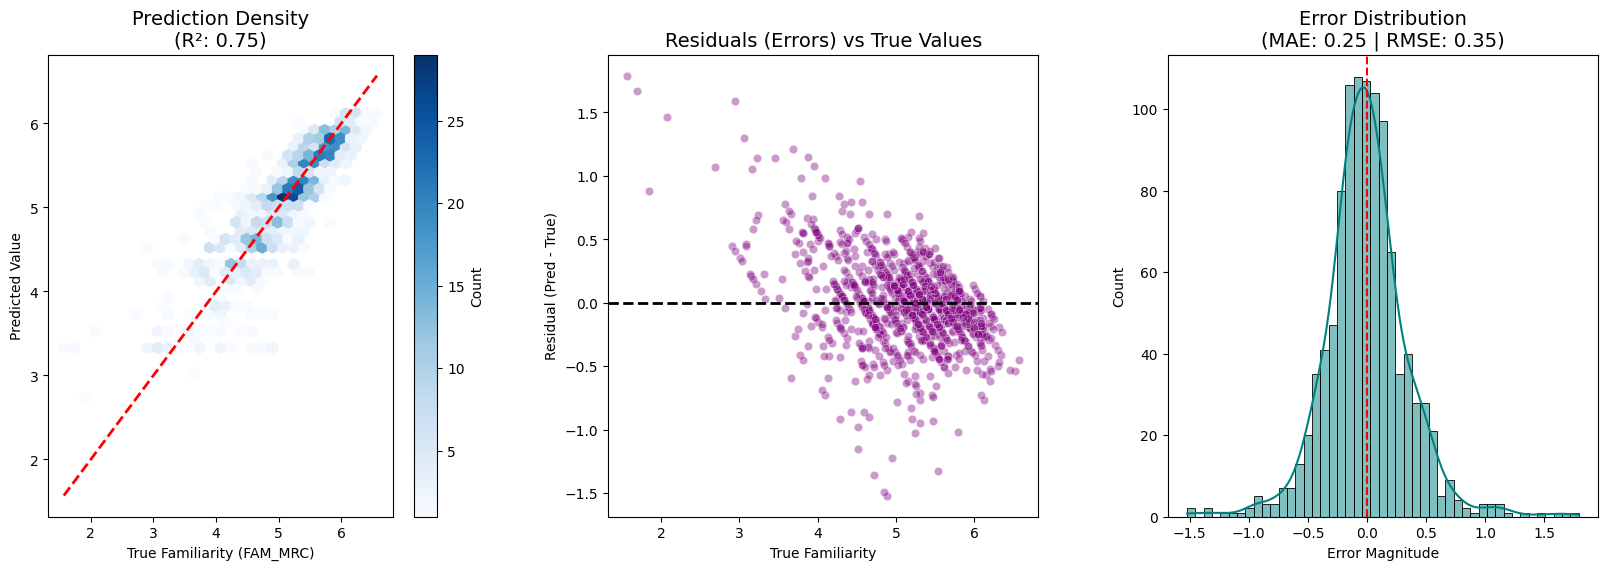

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define variables based on your dataframe
y_true = df_error_analysis[columns[0]]
y_pred = df_error_analysis[columns[1]]
residuals = y_pred - y_true

# 2. Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# 3. Setup Plotting Grid
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.3)

# --- CHART 1: Hexbin Plot (Better Version of your Scatter) ---
# This shows density to solve the overplotting issue in your original image
hb = axes[0].hexbin(y_true, y_pred, gridsize=30, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Count')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_title(f'Prediction Density\n(R²: {r2:.2f})', fontsize=14)
axes[0].set_xlabel('True Familiarity (FAM_MRC)')
axes[0].set_ylabel('Predicted Value')

# --- CHART 2: Residual Plot ---
# Shows if errors are systematic (e.g., if you always fail at low values)
sns.scatterplot(x=y_true, y=residuals, alpha=0.4, ax=axes[1], color='purple')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals (Errors) vs True Values', fontsize=14)
axes[1].set_xlabel('True Familiarity')
axes[1].set_ylabel('Residual (Pred - True)')

# --- CHART 3: Error Distribution ---
# Quantifies the "spread" of your error
sns.histplot(residuals, kde=True, ax=axes[2], color='teal')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title(f'Error Distribution\n(MAE: {mae:.2f} | RMSE: {rmse:.2f})', fontsize=14)
axes[2].set_xlabel('Error Magnitude')

plt.show()